**Scenerio:**

You've been employed by the city council of New York City to provide them with key weather insights, based on a text file with climate data over one year from July 2024 to Jun 2025. Use the provided dataset to answer the following question.

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

**Question 1.1**
Prepare your dataset to work with by:

a) Converting the NYCTempRecord.txt file to a CSV file called NYCTemps.csv

b) Using the following column headings: date, actual mean, actual min, actual max, average min, average max, record low, record high, record low year, record high year, actual precipitation, and record precipitation

In [10]:
# b
headings = 'date,actual mean,actual min,actual max,average min,average max,record low,record high,record low year,record high year,actual precipitation,average precipitation,record precipitation'
date = []
act_max = []
act_min = []
avg_max = []
avg_min = []

In [11]:
# a
with open('NYCTempRecord.txt', 'r') as txt_file:
    # print(txt_file.readline())
    txt_file.readline()
    with open('NYCTemps.csv', 'w') as csv_file:
        csv_file.write(headings + '\n')
        for line in txt_file:
            # print(line)
            csv_file.write(line)
            info = line.split(',')
            date.append(info[0])
            act_min.append(info[2])
            act_max.append(info[3])
            avg_min.append(info[4])
            avg_max.append(info[5])

**Question 1.2**
Create the following dictionaries, using the date as the key.

a) tempYearMaxAct, which contains the actual maximun precipitation for the year.

b) tempYearMinAct, which contains the actual minimun temperatures per day for the year.

c) tempYearMaxAvg, which contains the averaeg maximun temoerature per day for the year.

d) tempYearMinAvg, which contains thr average minumun temperatures per day for the year.

In [12]:
# a.
tempYearMaxAct = {}
# b.
tempYearMinAct = {}
# c.
tempYearMaxAvg = {}
# d.
tempYearMinAvg = {}

with open('NYCTemps.csv', 'r') as file:
    file.readline()
    #print(len(file.readlines()))
    for i in range(len(date)):
        # a.
        tempYearMaxAct[date[i]] = float(act_max[i])
        # b.
        tempYearMinAct[date[i]] = float(act_min[i])
        # c.
        tempYearMaxAvg[date[i]] = float(avg_max[i])
        # d.
        tempYearMinAvg[date[i]] = float(avg_min[i])

**Question 1.3**
Use the dictionaries created in the previous questions to find both the actual and average temperatures for the hottest day and coldest day of the year. Print these out to the console without changing th eorder of your dictionaries.

In [13]:
act_hottest_temp = pd.Series(tempYearMaxAct).max()
print("Actual temp for hottest day: " + act_hottest_temp)
avg_hottest_temp = pd.Series(tempYearMaxAvg).max()
print("Average temp for hottest day: " + avg_hottest_temp)
act_coldest_temp = pd.Series(tempYearMinAct).min()
print("Actual temp for coldest day: " + act_coldest_temp)
avg_coldest_temp = pd.Series(tempYearMinAvg).min()
print("Average temp for coldest day: " + avg_coldest_temp)

Actual temp for hottest day: 92
Average temp for hottest day: 84
Actual temp for coldest day: 19
Average temp for coldest day: 38


**Question 1.6** Convert the .csv file you created into a pandas dataframe.

In [16]:
df = pd.read_csv('NYCTemps.csv')

**Question 1.4**
Create the following Python lists:

a) precipYearMaxAct, which contains the actual maximun precipitation for the year.

b) precipYearMinAct, which contains the actual minumun precipitation for the year.

c) precipYearAvg, which contains the average minimun precipitation for the year.

In [14]:
precipYearMaxAct = df['actual precipitation']
precipYearMinAct = df['actual precipitation']
precipYearAvg = df['average precipitation']

**Question 1.5** Use the lists created in the previous question to find the days with the most and least precipitation, as well as the day the highest average precipitation. Print these out to the console without changing the order of your lists.

In [15]:
print(precipYearMaxAct.max())
print(precipYearMinAct.min())
print(precipYearAvg.min())

2.54
0.0
0.1


**Question 1.7** Create frequency diagrams to find the following information:

a) Find the hottest year on record by finding which year had the most record high termperatur days recorded.

b) Find the Coldest year on record by finding which year had the most record low temperatures days recorded.



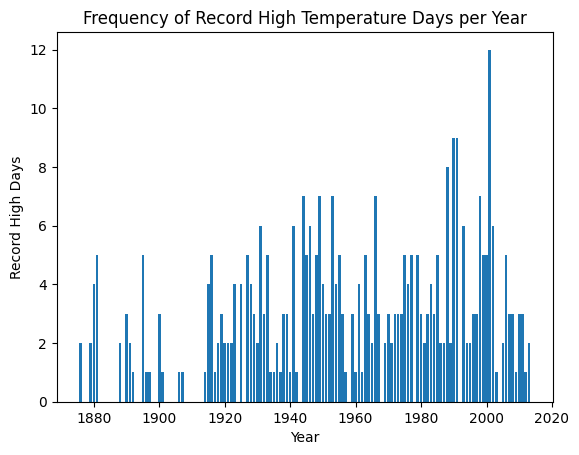

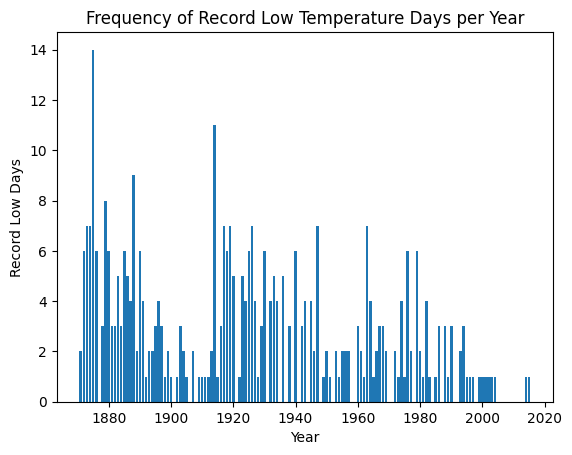

In [18]:
x_record_low_years = df['record low year'].sort_values().unique()
x_record_high_years = df['record high year'].sort_values().unique()

y_no_record_low_years = [df[df['record low year'] == year].shape[0] for year in x_record_low_years]
y_no_record_high_years = [df[df['record high year'] == year].shape[0] for year in x_record_high_years]

# a.
plt.title('Frequency of Record High Temperature Days per Year')
plt.xlabel('Year')
plt.ylabel('Record High Days')
plt.bar(x_record_high_years, y_no_record_high_years)
plt.show()
# b.
plt.title('Frequency of Record Low Temperature Days per Year')
plt.xlabel('Year')
plt.ylabel('Record Low Days')
plt.bar(x_record_low_years, y_no_record_low_years)
plt.show()

**Question 1.8** Create a function that will allow you plot the following graphs with MatPlotLib:

a) Plot the highest temperature in each month by using a bar chart. Your x-axis should have the months and your y-axis should have the temperatures

b) Plot your average, highest and lowest precipitation for the month of december on a line chart. Your x-axis should be the days and your y-axis should have the temperatures.

c) Use a Scatter chart to plot the recoerd high and record low temperature. Track the years on you x-axis and the temperatures on you Y-axis. Make the dots for your high temperatures red and the dots for your cold temperatures blue.

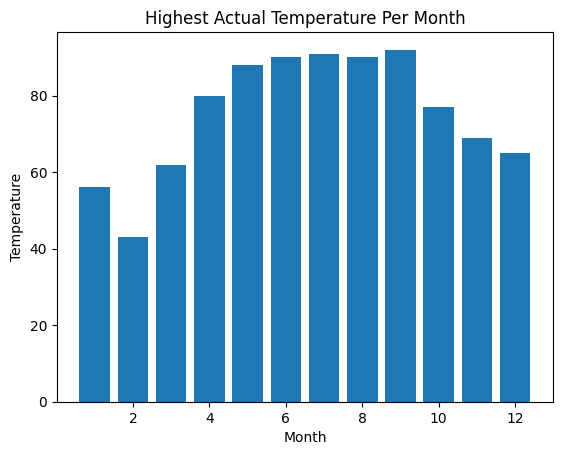

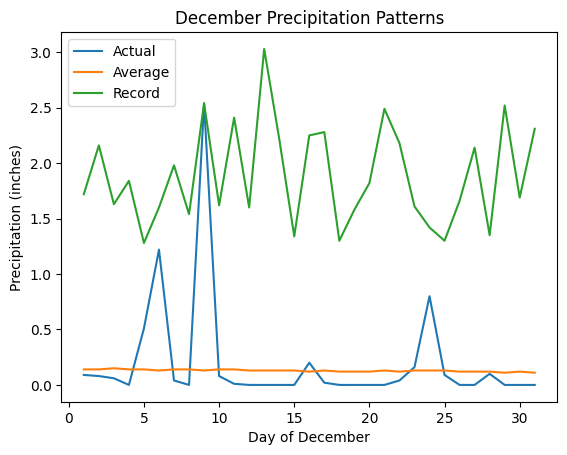

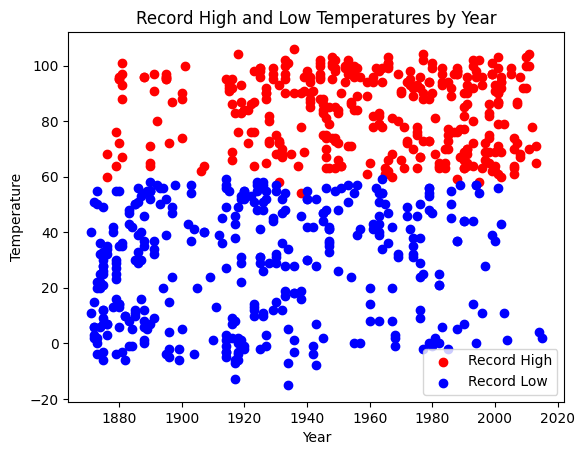

In [20]:
df['date'] = pd.to_datetime(df['date'])
df['Month'] = df['date'].dt.month
df['Day'] = df['date'].dt.day
df['Year'] = df['date'].dt.year

# a) Bar chart of highest actual temperature per month
max_temps = df.groupby('Month')['actual max'].max()
plt.bar(max_temps.index, max_temps.values)
plt.title('Highest Actual Temperature Per Month')
plt.xlabel('Month')
plt.ylabel('Temperature')
plt.show()

 # b) Line chart: average, high, and low precipitation for December
december = df[df['Month'] == 12]
plt.plot(december['Day'], december['actual precipitation'], label='Actual')
plt.plot(december['Day'], december['average precipitation'], label='Average')
plt.plot(december['Day'], december['record precipitation'], label='Record')
plt.title('December Precipitation Patterns')
plt.xlabel('Day of December')
plt.ylabel('Precipitation (inches)')
plt.legend()
plt.show()

# c) Scatter plot of record highs and lows vs years
plt.scatter(df['record high year'], df['record high'], color='red', label='Record High')
plt.scatter(df['record low year'], df['record low'], color='blue', label='Record Low')
plt.title('Record High and Low Temperatures by Year')
plt.xlabel('Year')
plt.ylabel('Temperature')
plt.legend()
plt.show()

**Question 1.9** Write a Report containig each of the previous question, with a short paragraph explaining the insight that you can gain from each respective graph

